=== Dataset Overview ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    int64  
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(6), object(4)
memory usage: 83.7+ KB
None

Missing Values per Column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare           

/tmp/ipykernel_496/1921733594.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_496/1921733594.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


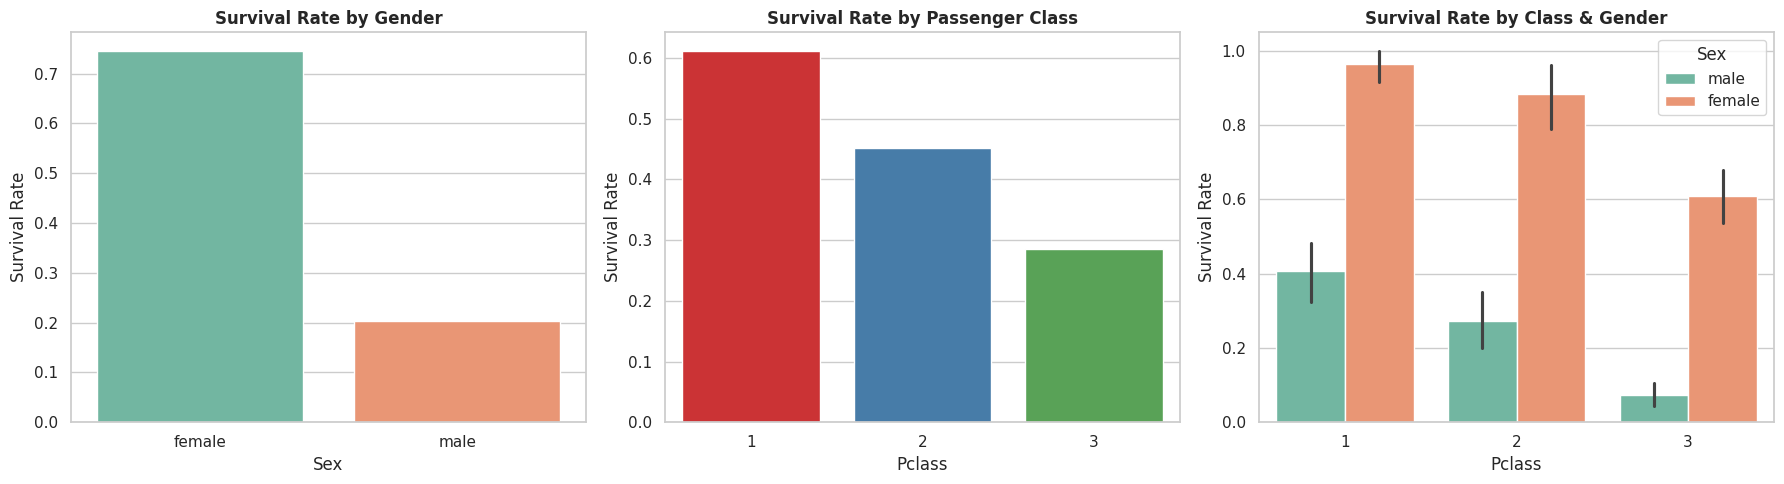

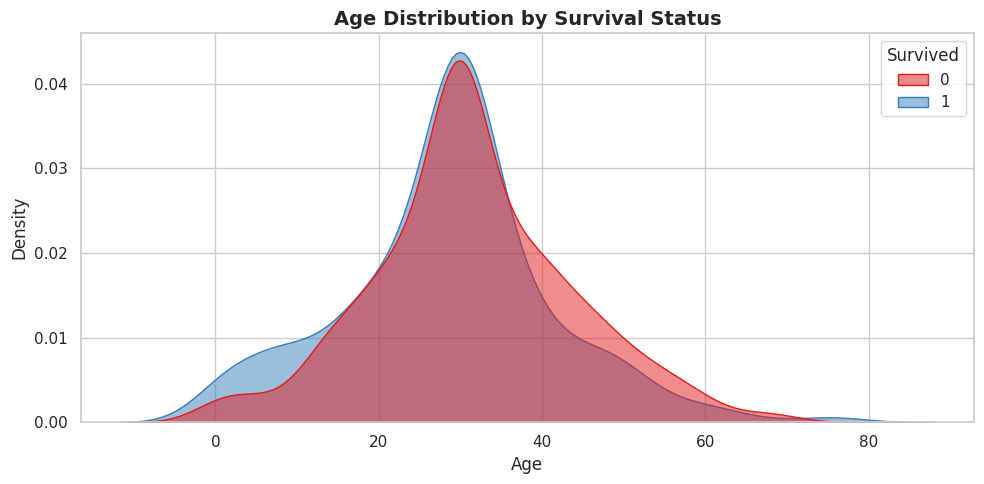

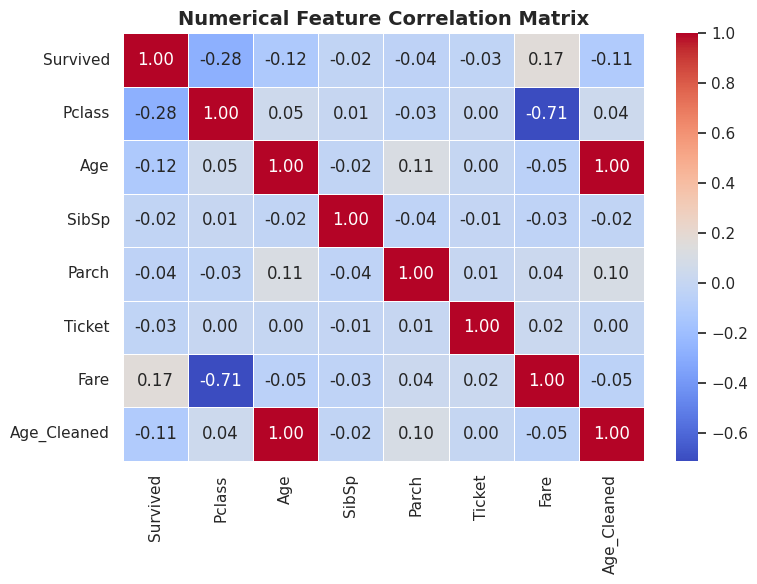

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set visual theme
sns.set_theme(style="whitegrid")

# 1. Load Dataset
df = pd.read_csv("titanic.csv")

# 2. Exploratory Data Inspection
print("=== Dataset Overview ===")
print(df.info())
print("\nMissing Values per Column:")
print(df.isnull().sum())

# Clean/impute missing Age values with median for EDA
df["Age_Cleaned"] = df["Age"].fillna(df["Age"].median())

# 3. Survival Rate Analysis by Categorical Features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Survival Rate by Gender
sns.barplot(
    data=df,
    x="Sex",
    y="Survived",
    ax=axes[0],
    palette="Set2",
    errorbar=None,
)
axes[0].set_title("Survival Rate by Gender", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Survival Rate")

# Survival Rate by Passenger Class
sns.barplot(
    data=df,
    x="Pclass",
    y="Survived",
    ax=axes[1],
    palette="Set1",
    errorbar=None,
)
axes[1].set_title(
    "Survival Rate by Passenger Class", fontsize=12, fontweight="bold"
)
axes[1].set_ylabel("Survival Rate")

# Survival Rate by Class and Gender Combined
sns.barplot(data=df, x="Pclass", y="Survived", hue="Sex", ax=axes[2], palette="Set2")
axes[2].set_title("Survival Rate by Class & Gender", fontsize=12, fontweight="bold")
axes[2].set_ylabel("Survival Rate")

plt.tight_layout()
plt.show()

# 4. Age Distribution by Survival Status
plt.figure(figsize=(10, 5))
sns.kdeplot(
    data=df,
    x="Age_Cleaned",
    hue="Survived",
    common_norm=False,
    fill=True,
    alpha=0.5,
    palette="Set1",
)
plt.title("Age Distribution by Survival Status", fontsize=14, fontweight="bold")
plt.xlabel("Age")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

# 5. Correlation Matrix Heatmap
plt.figure(figsize=(8, 6))
numeric_cols = df.select_dtypes(include=["float64", "int64"]).drop(
    columns=["PassengerId"]
)
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Numerical Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()